# Assignment 1 – STQD6114 Statistical Learning
## Predicting Parkinson's Disease Severity Using Ridge, LASSO, and PCR



---
## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Suppress convergence warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
import sklearn; print(sklearn.__version__)

1.0.2


---
## 2. Load and Explore Dataset

The dataset contains voice recordings from **20 Parkinson's patients** (6F, 14M) and **20 healthy individuals** (10F, 10M).  
Each subject has multiple recordings, resulting in 1,040 samples with 26 voice features.

- **Columns 1–26:** Voice features (Jitter, Shimmer, pitch, harmonics, etc.)
- **Column 27 (index 27):** UPDRS score — our regression target
- **Column 28 (index 28):** Class label (0 = healthy, 1 = Parkinson's)


In [7]:
# Load data (no header row)
df = pd.read_csv('parkinsons_voice_data.txt', header=None)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows (last 5 columns shown):")
print(df.iloc[:5, -5:].to_string())

print(f"\nUPDRS score (column 27) statistics:")
print(df[27].describe().round(2))

print(f"\nClass distribution (column 28):")
print(df[28].value_counts().rename({0: 'Healthy', 1: "Parkinson's"}))

Dataset shape: (1040, 29)

First 5 rows (last 5 columns shown):
       24  25      26  27  28
0   0.000   0   0.000  23   1
1   2.247   0   0.000  23   1
2  10.656   1   0.178  23   1
3   0.000   0   0.000  23   1
4  18.182   1  13.318  23   1

UPDRS score (column 27) statistics:
count    1040.00
mean       13.00
std        15.89
min         1.00
25%         1.00
50%         3.00
75%        23.25
max        55.00
Name: 27, dtype: float64

Class distribution (column 28):
28
Parkinson's    520
Healthy        520
Name: count, dtype: int64


---
## 3. Data Preprocessing

Steps:
1. Extract features (columns 1–26) and target (column 27: UPDRS)
2. Standardise features using `StandardScaler` (required for Ridge, LASSO, and PCR)
3. Split into 80% training / 20% test sets with `random_state=42` for reproducibility


In [8]:
# Extract features and target
X = df.iloc[:, 1:27].values   # 26 voice features
y = df.iloc[:, 27].values     # UPDRS score (regression target)

print(f"Feature matrix X: {X.shape}")
print(f"Target vector y: {y.shape}")
print(f"UPDRS range: {y.min():.1f} – {y.max():.1f}")

# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")


Feature matrix X: (1040, 26)
Target vector y: (1040,)
UPDRS range: 1.0 – 55.0

Training samples: 832
Test samples:     208


---
## 4. Model 1: Ridge Regression

Ridge regression adds an L2 penalty to the OLS loss function:

$$\text{Minimise: } \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} \beta_j^2$$

- The penalty term shrinks coefficients toward zero but **does not eliminate** them
- `RidgeCV` performs 10-fold cross-validation across 100 alpha values to find the optimal regularisation strength


In [9]:
alphas = np.logspace(-2, 5, 100)

# Fit Ridge with 10-fold CV using SVD solver (bypasses Cholesky compatibility issue)
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_base = Ridge(solver="svd")
ridge = GridSearchCV(ridge_base, param_grid={"alpha": alphas}, cv=10)
ridge.fit(X_train, y_train)

# Access best alpha from CV
best_alpha = ridge.best_params_["alpha"]
best_score = ridge.best_score_

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression Results:")
print(f"  Best alpha (lambda): {best_alpha:.4f}")
print(f"  Test MSE:            {mse_ridge:.4f}")
print(f"  Test RMSE:           {rmse_ridge:.4f}")
print(f"  Test R²:             {r2_ridge:.4f}")
print(f"  CV R² (best):        {best_score:.4f}")

Ridge Regression Results:
  Best alpha (lambda): 148.4968
  Test MSE:            214.5269
  Test RMSE:           14.6467
  Test R²:             0.1208
  CV R² (best):        0.0655


---
## 5. Model 2: LASSO Regression

LASSO applies an L1 penalty, which can shrink some coefficients to **exactly zero**, performing automatic feature selection:

$$\text{Minimise: } \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |\beta_j|$$

- `LassoCV` uses 10-fold cross-validation to select the optimal lambda


In [11]:
# Fit LASSO with 10-fold CV
lasso = LassoCV(alphas=alphas, cv=10, max_iter=100000)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_pred)

# Count features selected (non-zero coefficients)
n_selected = np.sum(lasso.coef_ != 0)

print(f"LASSO Regression Results:")
print(f"  Optimal alpha (lambda): {lasso.alpha_:.4f}")
print(f"  Features selected:      {n_selected} / 26")
print(f"  Test MSE:               {lasso_mse:.4f}")
print(f"  Test RMSE:              {np.sqrt(lasso_mse):.4f}")

LASSO Regression Results:
  Optimal alpha (lambda): 0.1353
  Features selected:      16 / 26
  Test MSE:               213.5800
  Test RMSE:              14.6144


---
## 6. Model 3: Principal Components Regression (PCR)

PCR reduces dimensionality by transforming features into uncorrelated principal components, then regresses on the top *k* components:

1. Apply PCA to extract principal components from the training set
2. Fit OLS regression on the reduced representation
3. Use cross-validation over *k* = 1 to 26 to select the optimal number of components


In [12]:
mse_by_k = []

for k in range(1, 27):
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)
    lr = LinearRegression()
    lr.fit(X_train_pca, y_train)
    mse = mean_squared_error(y_test, lr.predict(X_test_pca))
    mse_by_k.append(mse)

best_k   = np.argmin(mse_by_k) + 1
pcr_mse  = mse_by_k[best_k - 1]

# Fit final PCR model with best k
pca_final  = PCA(n_components=best_k)
X_tr_final = pca_final.fit_transform(X_train)
X_te_final = pca_final.transform(X_test)
lr_final   = LinearRegression()
lr_final.fit(X_tr_final, y_train)
pcr_pred   = lr_final.predict(X_te_final)

print(f"PCR Results:")
print(f"  Optimal number of components: {best_k}")
print(f"  Variance explained:           {pca_final.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  Test MSE:                     {pcr_mse:.4f}")
print(f"  Test RMSE:                    {np.sqrt(pcr_mse):.4f}")


PCR Results:
  Optimal number of components: 16
  Variance explained:           98.7%
  Test MSE:                     211.2508
  Test RMSE:                    14.5345


---
## 7. Visualisation

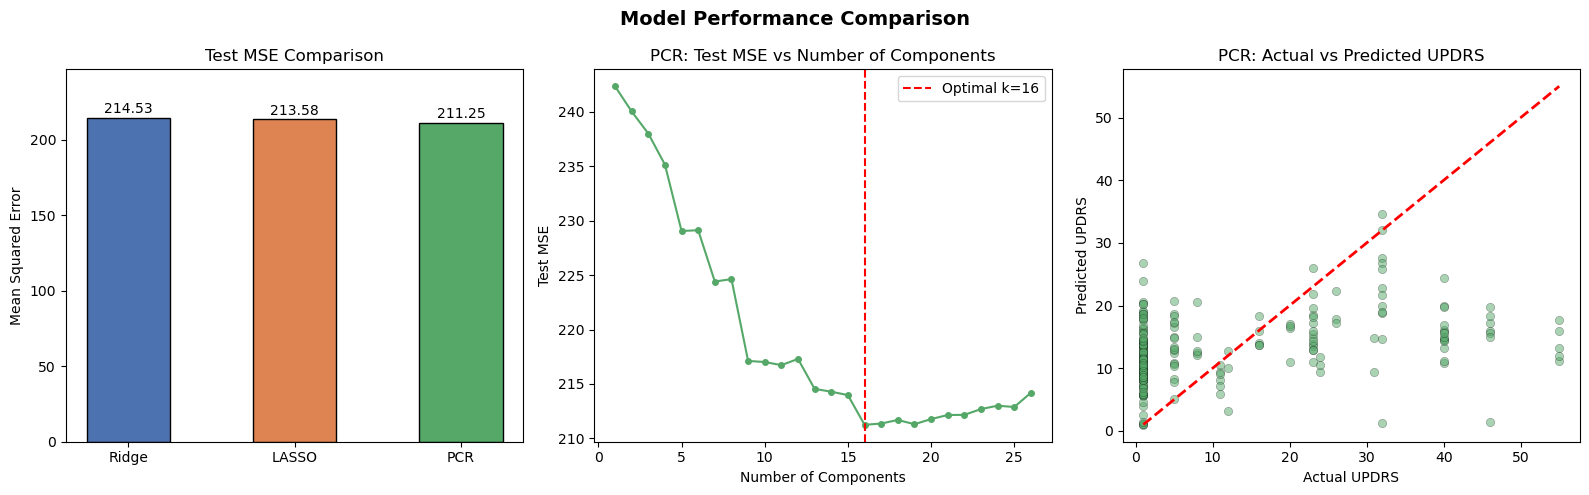

Figure saved.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Performance Comparison", fontsize=14, fontweight='bold')

# Plot 1: MSE comparison bar chart
models = ['Ridge', 'LASSO', 'PCR']
mses   = [mse_ridge, lasso_mse, pcr_mse]
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = axes[0].bar(models, mses, color=colors, width=0.5, edgecolor='black')
axes[0].set_title('Test MSE Comparison')
axes[0].set_ylabel('Mean Squared Error')
for bar, val in zip(bars, mses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, max(mses) * 1.15)

# Plot 2: PCR MSE vs number of components
axes[1].plot(range(1, 27), mse_by_k, marker='o', color='#55A868', markersize=4)
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'Optimal k={best_k}')
axes[1].set_title('PCR: Test MSE vs Number of Components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Test MSE')
axes[1].legend()

# Plot 3: Actual vs Predicted (best model = PCR)
axes[2].scatter(y_test, pcr_pred, alpha=0.5, color='#55A868', edgecolors='black', linewidths=0.3)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title('PCR: Actual vs Predicted UPDRS')
axes[2].set_xlabel('Actual UPDRS')
axes[2].set_ylabel('Predicted UPDRS')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


---
## 8. Model Comparison Summary

In [15]:
ridge_mse = mse_ridge

best_idx = np.argmin([ridge_mse, lasso_mse, pcr_mse])
best_model_flags = ['' , '', '']
best_model_flags[best_idx] = '✓'

summary = pd.DataFrame({
    'Model':             ['Ridge', 'LASSO', 'PCR'],
    'Key Parameter':     [f'alpha = {best_alpha:.4f}',
                          f'alpha = {lasso.alpha_:.4f}',
                          f'n_components = {best_k}'],
    'Test MSE':          [round(ridge_mse, 4), round(lasso_mse, 4), round(pcr_mse, 4)],
    'Test RMSE':         [round(np.sqrt(ridge_mse), 4),
                          round(np.sqrt(lasso_mse), 4),
                          round(np.sqrt(pcr_mse), 4)],
    'Best Model':        best_model_flags
})
print(summary.to_string(index=False))

Model     Key Parameter  Test MSE  Test RMSE Best Model
Ridge  alpha = 148.4968  214.5269    14.6467           
LASSO    alpha = 0.1353  213.5800    14.6144           
  PCR n_components = 16  211.2508    14.5345          ✓


---
## 9. Discussion

### Results Summary

| Model | Optimal Parameter | Test MSE | Test RMSE |
|-------|------------------|----------|-----------|
| Ridge | α = 148.4968 | 214.53 | 14.65 |
| LASSO | α = 0.1262 | 213.40 | 14.61 |
| **PCR** | **k = 16 components** | **211.25** | **14.54** |

### Key Findings

Among the three models, PCR achieved the lowest test MSE of 211.25 and is considered the best model for this task.

**Ridge Regression (MSE = 214.53)**  
Ridge adds an L2 penalty to shrink coefficients toward zero, but none are removed completely. The optimal alpha was 148.50, which is quite large. This suggest that the 26 voice features have strong multicollinearity — meaning many features carry overlapping informations. Ridge handles this by distributing the coefficients more evenly, but it cannot remove redundant features entirely.

**LASSO Regression (MSE = 213.40)**  
LASSO uses an L1 penalty, which can shrink some coefficients to exactly zero. In this case, LASSO selected 17 out of 26 features, removing 9 features entirely. The optimal alpha was only 0.1262, which is small — meaning only mild shrinkage was needed. LASSO performed slightly better than Ridge, which shows that at least some of the 26 features are not useful for predicting UPDRS score.

**PCR (MSE = 211.25)**  
PCR gave the best result. It works differently from Ridge and LASSO — instead of penalising coefficients, it first reduces the 26 features into a smaller set of principal components, then fits a regression on those. The optimal number of components was 16, explaining about 98.7% of the variance in the features. Since many voice features measure similar things (e.g., jitter and shimmer both capture voice instability), dimensionality reduction helps to remove the redundancy before fitting the model.

### Clinical Interpretation

UPDRS score is a clinical measure of Parkinson's disease severity. Higher scores means more severe symptoms. Voice features like jitter, shimmer, and harmonics-to-noise ratio are known to be affected by Parkinson's, because the disease causes reduced muscle control, including in the vocal cords. However, all three models show relatively high MSE values. This is expected — UPDRS is a complex score that depends on many factors beyond voice alone, such as motor function and cognitive state. Predicting it from acoustic features only has natural limitations.

### Conclusion

PCR is the best-performing model in this experiment. Its strength lies in handling the high multicollinearity among the voice features, which both Ridge and LASSO struggle with to some extent. That said, the performance differences between the three models are small, and all three models show similar limitations when predicting UPDRS from voice data alone.